In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Import Libraries & Load Data

import pandas as pd

df = pd.read_csv(r"C:\Users\sanan\Downloads\Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Basic Inspection

print(df.shape)
print(df.columns)
df.info()
df.describe()

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
#Check Missing Values

df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [5]:
df = df.dropna()  # or use fillna()

In [6]:
#Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
#Encode Target Variable (Crop Label)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [9]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

In [10]:
#Feature & Target Split

X = df.drop('label', axis=1)
y = df['label']

In [11]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
# Final Check

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1760, 7) (440, 7)
(1760,) (440,)


In [14]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [15]:
#Check Missing & Duplicates

print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


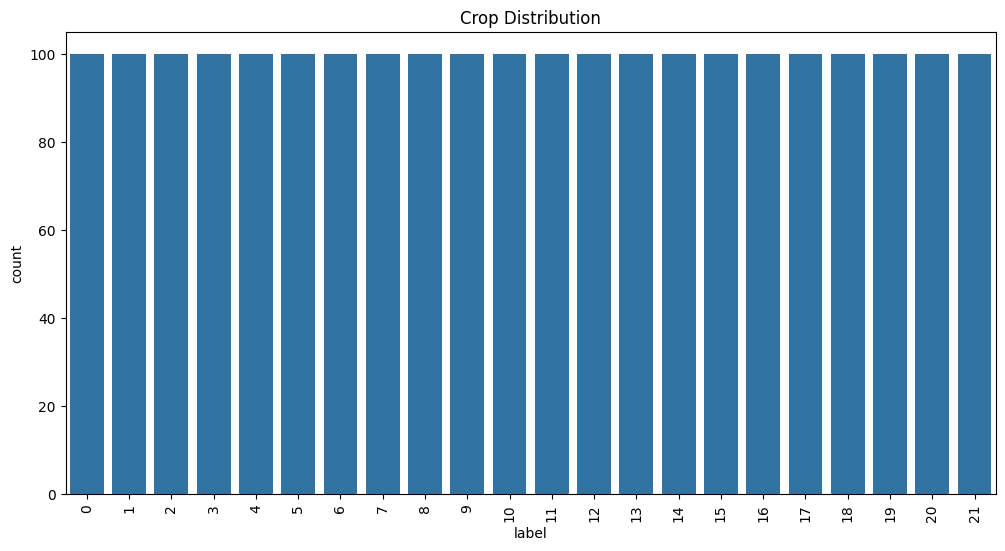

In [17]:
#Target Variable Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

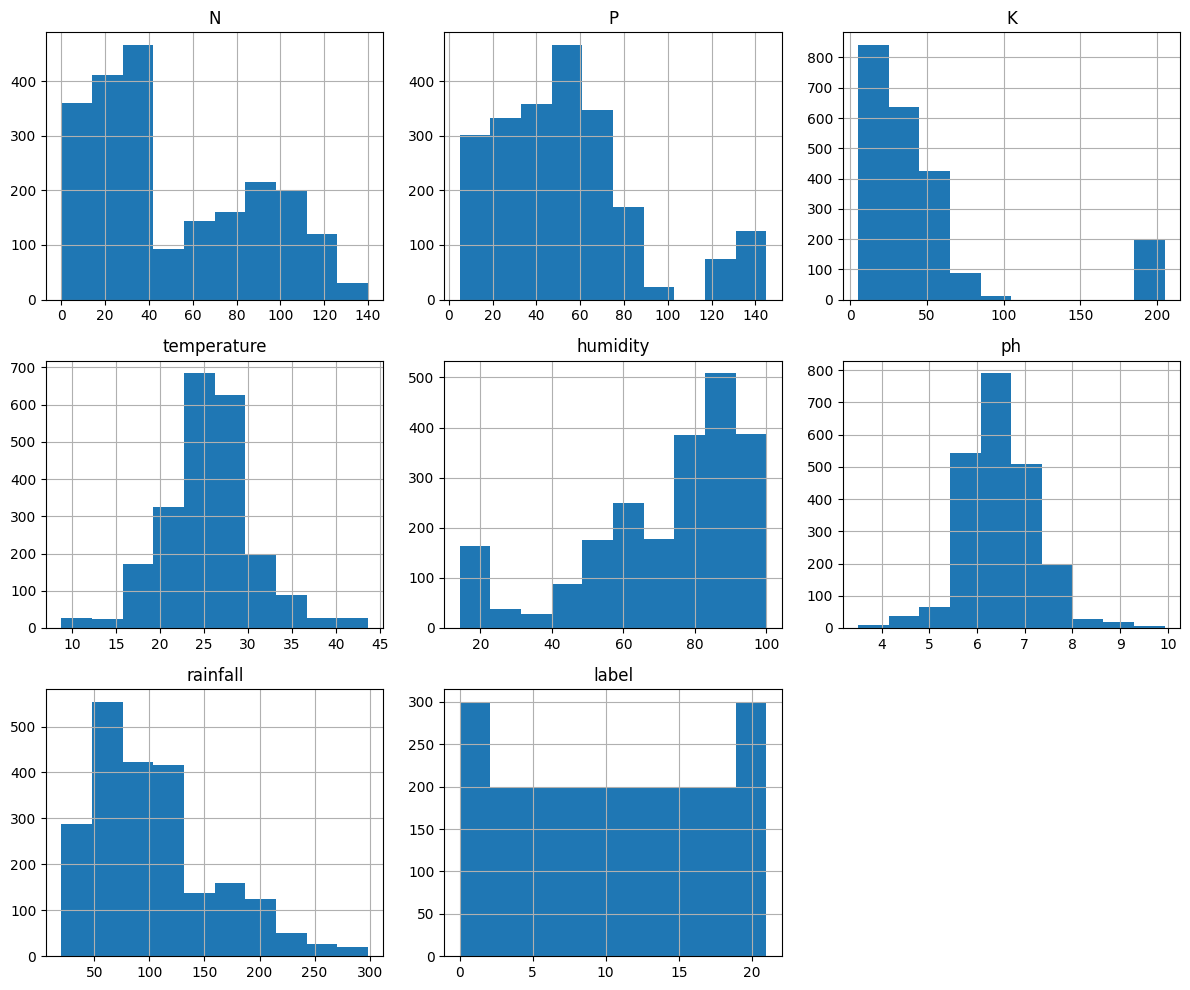

In [19]:
#Feature Distribution

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

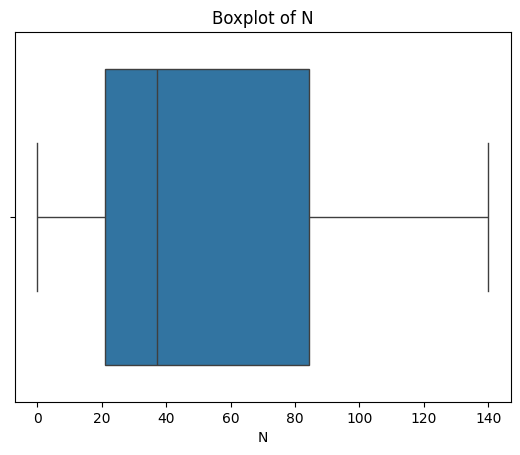

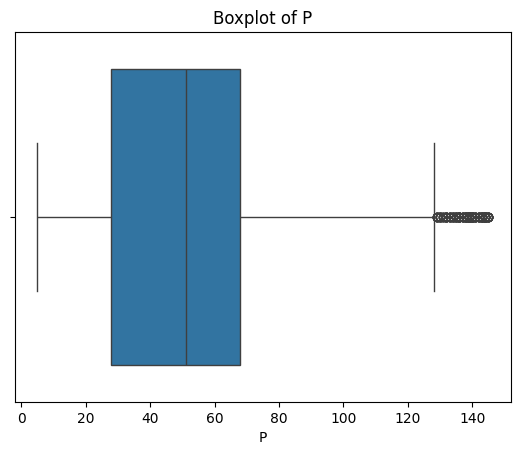

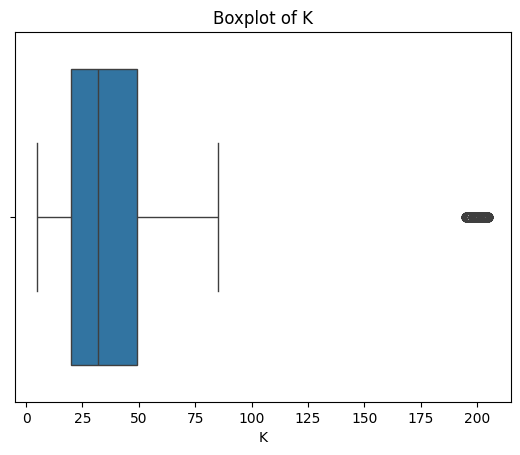

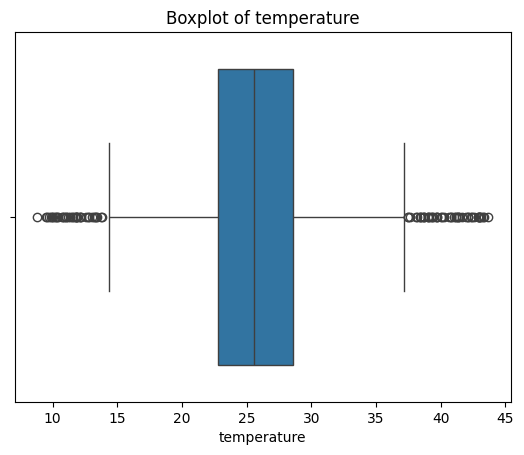

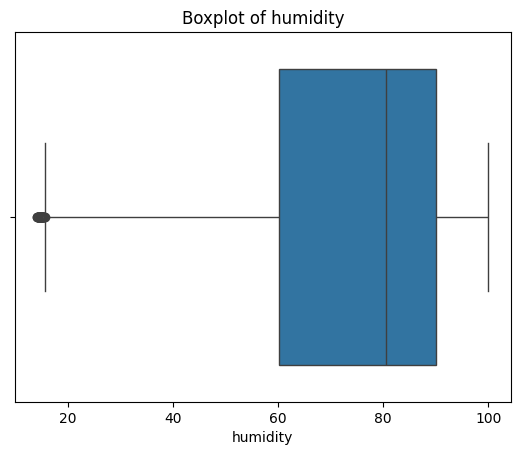

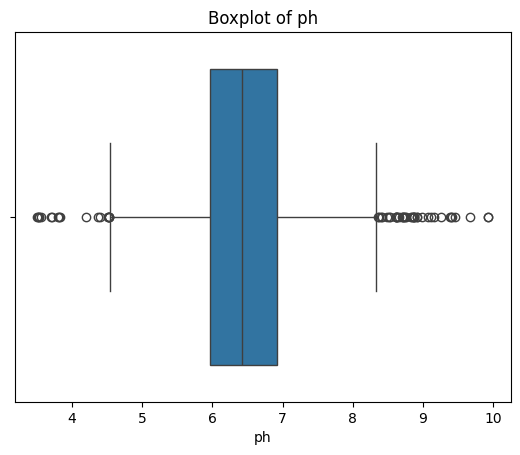

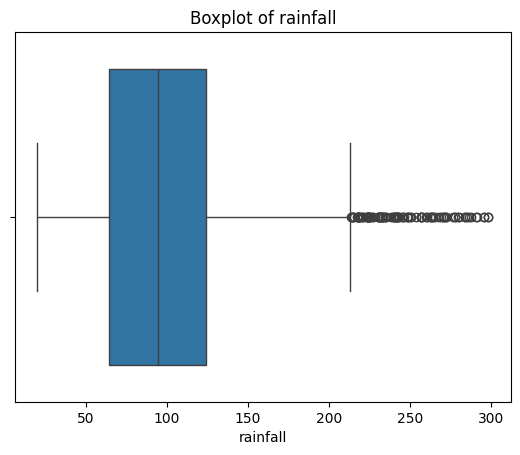

In [20]:
#Boxplots

for col in df.columns[:-1]:  # exclude label
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

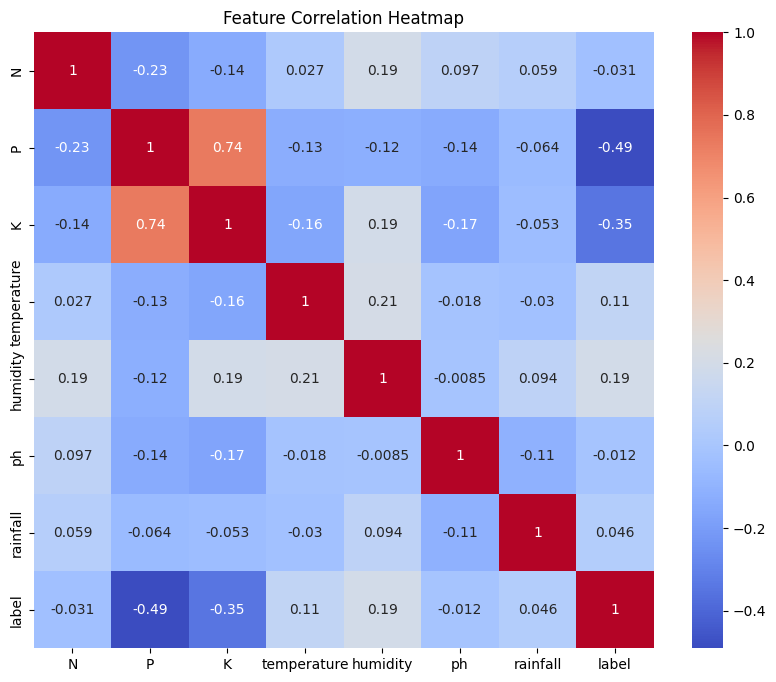

In [21]:
#Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

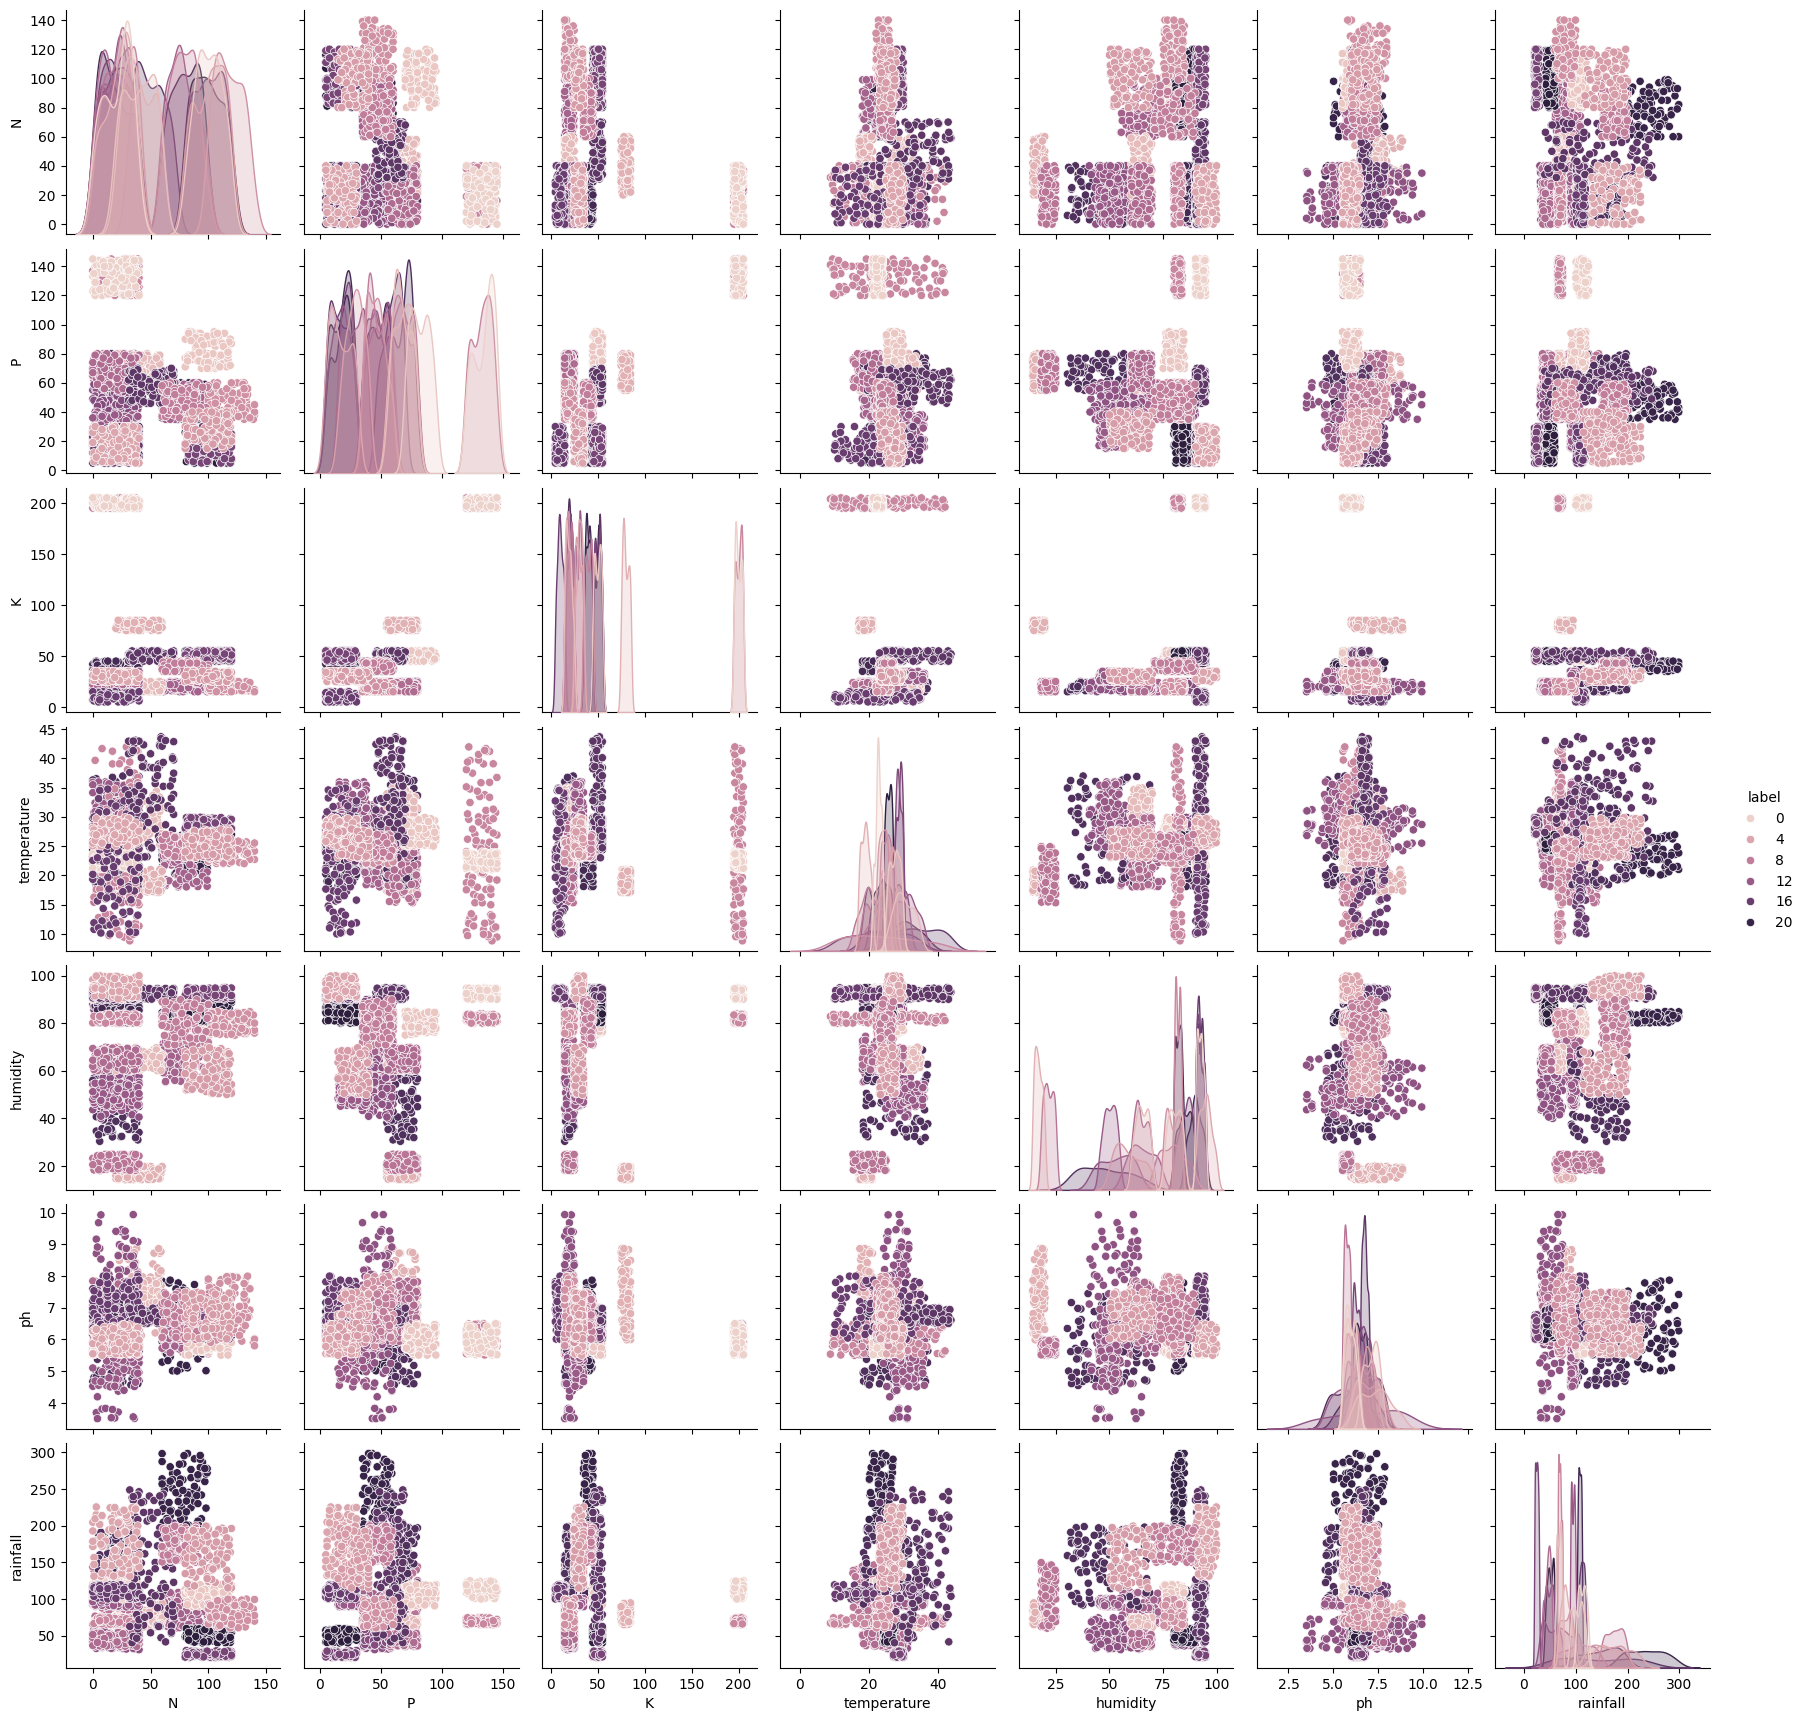

In [22]:
#Pairplot

sns.pairplot(df, hue='label')
plt.show()

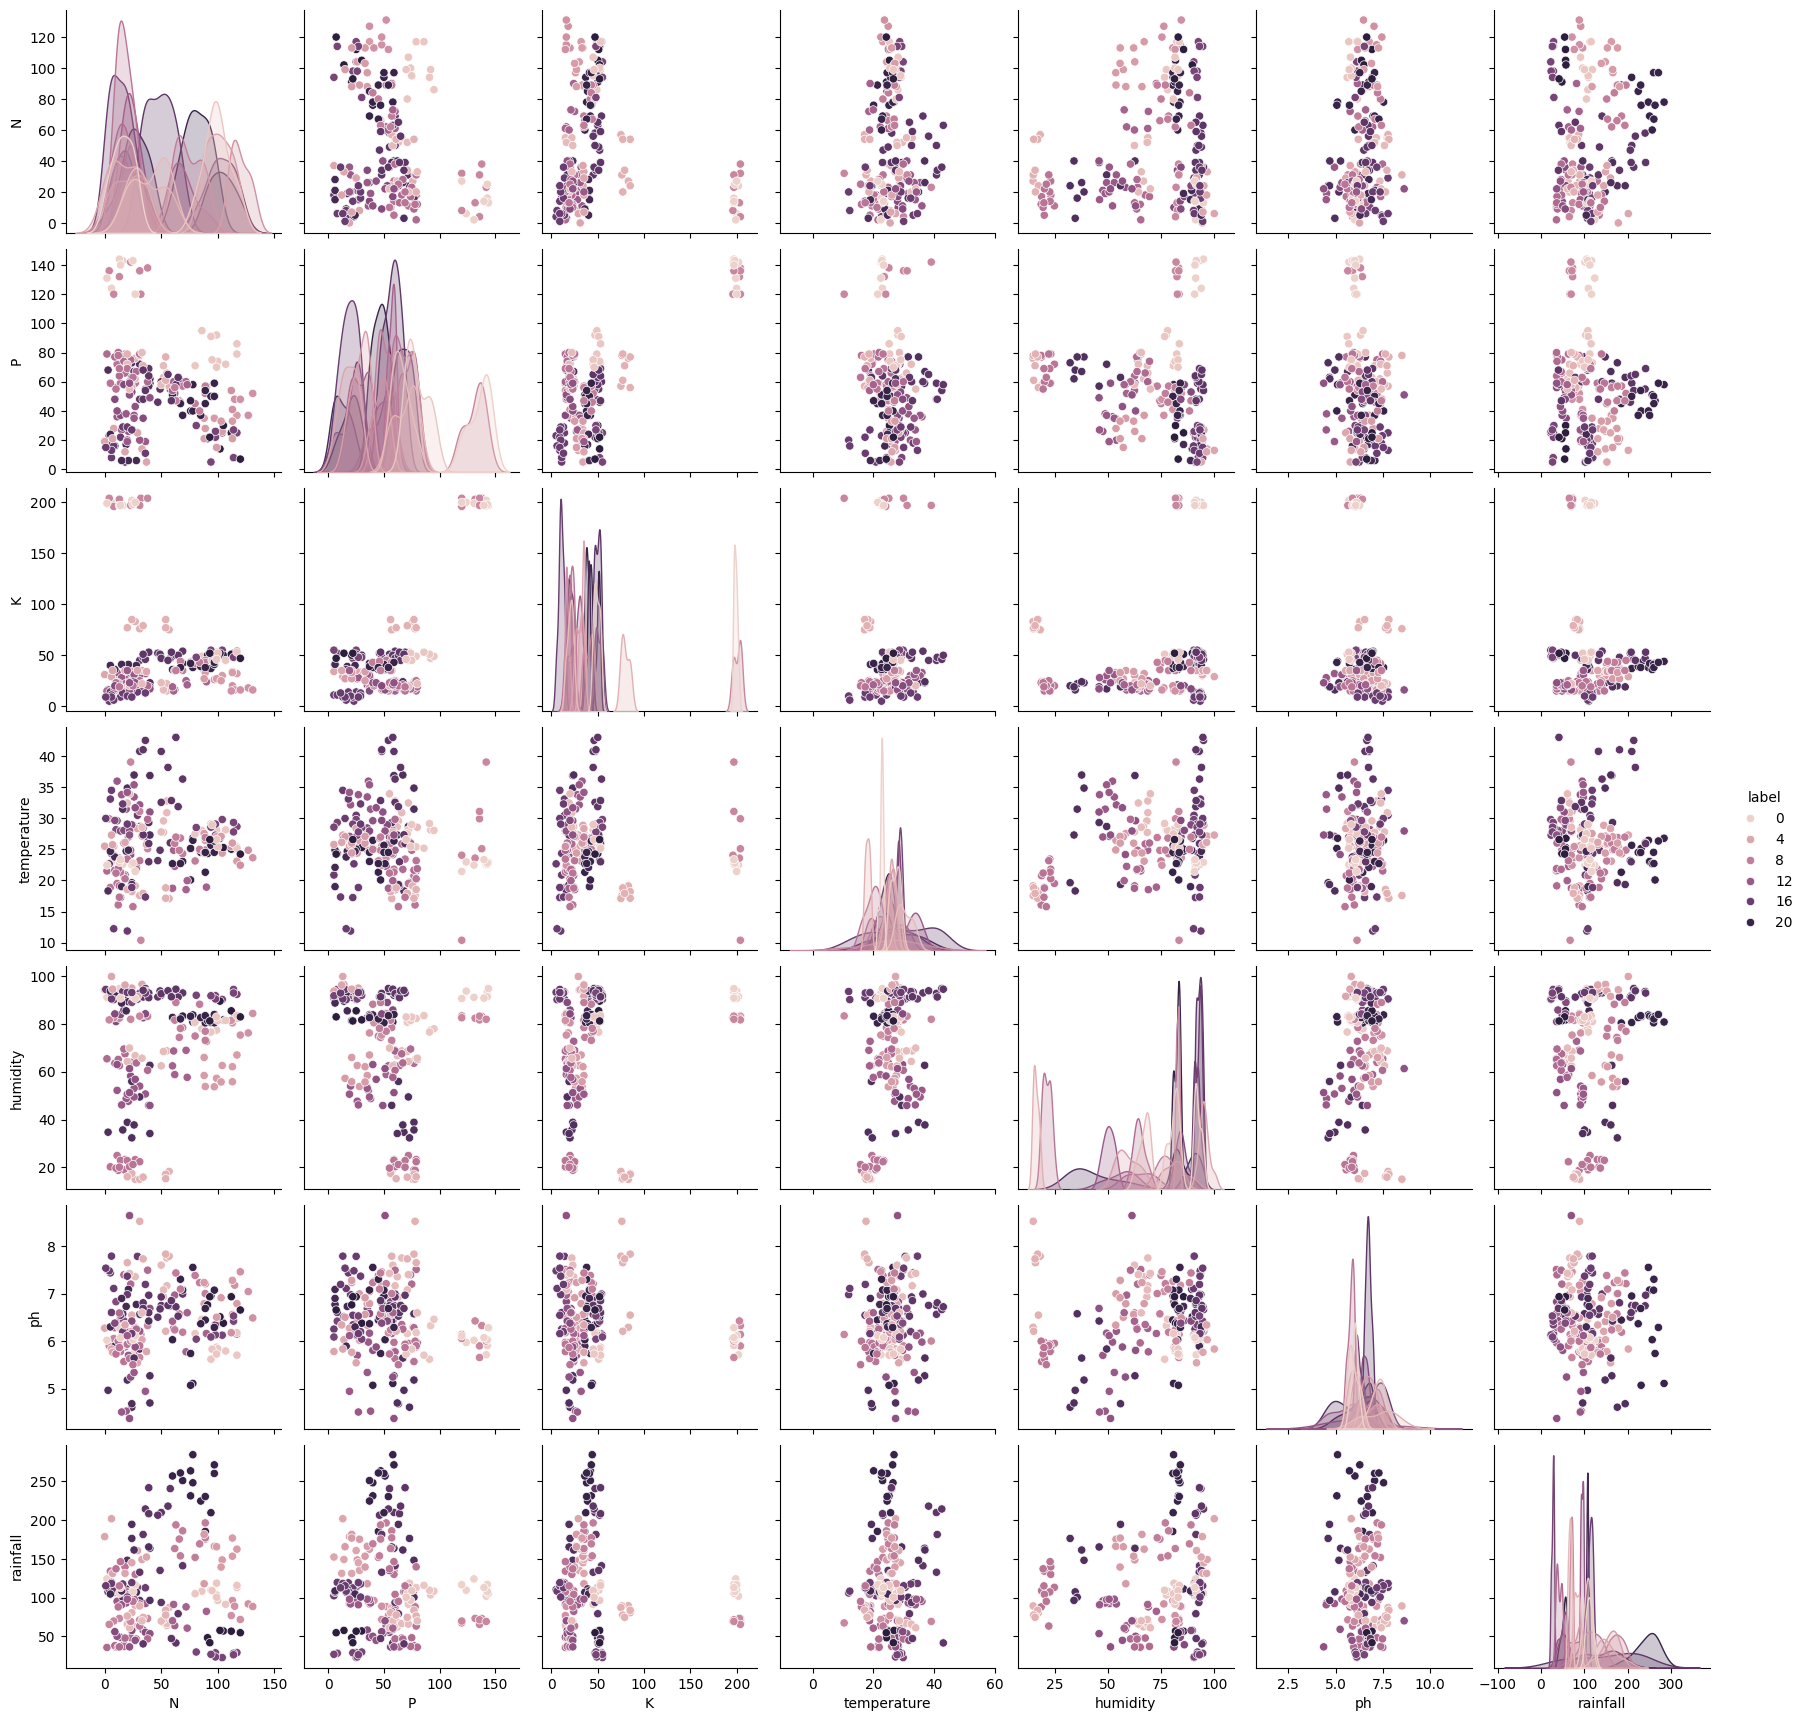

In [23]:
sns.pairplot(df.sample(200), hue='label')

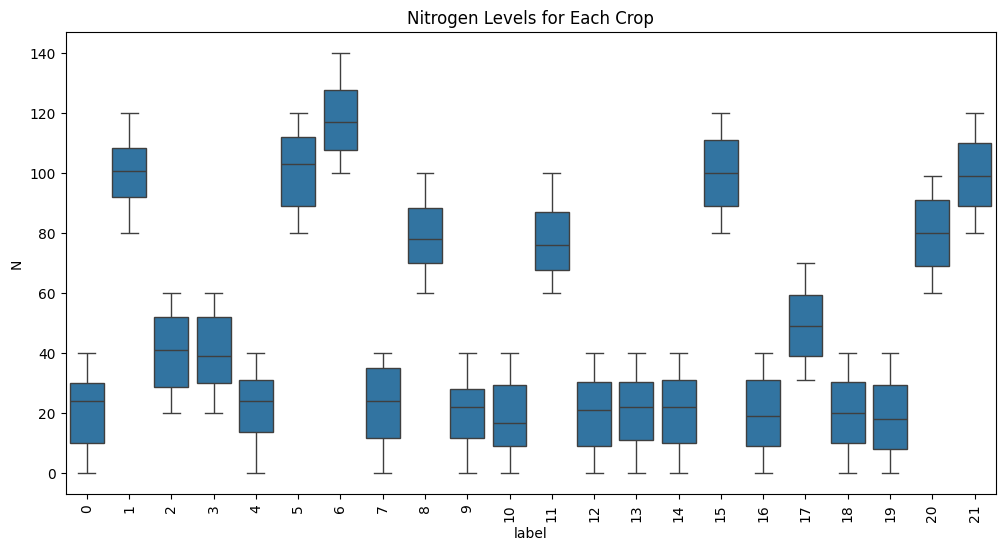

In [24]:
#Feature vs Target Analysis

plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='N', data=df)
plt.xticks(rotation=90)
plt.title("Nitrogen Levels for Each Crop")
plt.show()

In [25]:
#Define Features (X) and Target (y)

X = df.drop('label', axis=1)
y = df['label']

In [26]:
#Split the Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # ensures reproducibility
    stratify=y          # maintains class balance
)

In [27]:
#Verify the Split

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


In [28]:
#Check Class Distribution

print("Training set distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting set distribution:\n", y_test.value_counts(normalize=True))

Training set distribution:
 label
16    0.045455
7     0.045455
9     0.045455
13    0.045455
6     0.045455
1     0.045455
10    0.045455
14    0.045455
5     0.045455
15    0.045455
0     0.045455
2     0.045455
18    0.045455
11    0.045455
20    0.045455
21    0.045455
8     0.045455
12    0.045455
19    0.045455
17    0.045455
4     0.045455
3     0.045455
Name: proportion, dtype: float64

Testing set distribution:
 label
16    0.045455
1     0.045455
6     0.045455
11    0.045455
3     0.045455
20    0.045455
2     0.045455
21    0.045455
19    0.045455
13    0.045455
7     0.045455
12    0.045455
0     0.045455
9     0.045455
8     0.045455
5     0.045455
4     0.045455
17    0.045455
10    0.045455
14    0.045455
18    0.045455
15    0.045455
Name: proportion, dtype: float64


In [29]:
#Import Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
#Train Models

#Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [31]:
#Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
#Predictions

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [33]:
#Evaluate Models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
#Decision Tree Evaluation

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9795454545454545

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16 

In [35]:
#Random Forest Evaluation

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16 

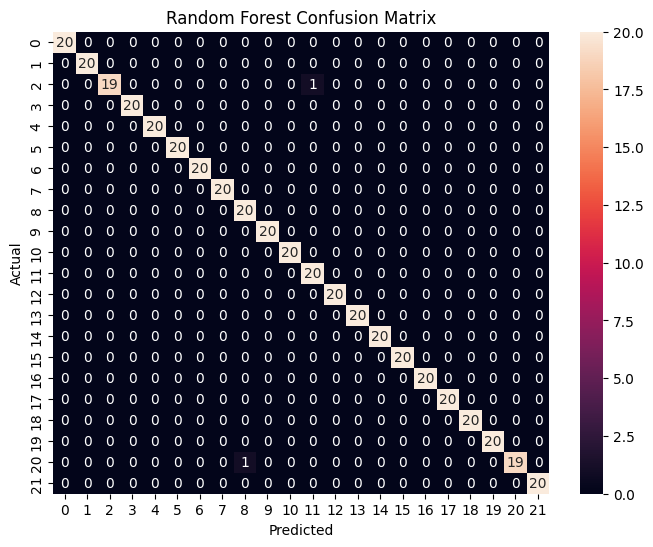

In [36]:
#Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
#Compare Models

dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Decision Tree Accuracy: 0.9795
Random Forest Accuracy: 0.9955


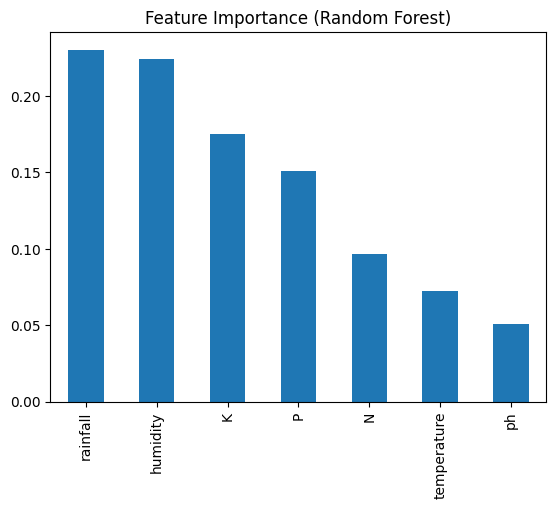

In [38]:
#Feature Importance

import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [39]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

In [40]:
#Cross-Validation

from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_model, X, y, cv=5)

print("Random Forest CV Scores:", rf_cv)
print("Mean CV Accuracy:", rf_cv.mean())

Random Forest CV Scores: [0.99772727 0.99318182 0.99772727 0.99545455 0.98863636]
Mean CV Accuracy: 0.9945454545454545


In [41]:
#Overfitting Check

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9954545454545455


In [42]:
#Model Comparison Table

import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_acc, rf_acc]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.979545
1  Random Forest  0.995455


In [43]:
#Define Prediction Function

def predict_crop(input_data, model, scaler, label_encoder):
    # Convert input to DataFrame
    import pandas as pd
    input_df = pd.DataFrame([input_data])

    # Scale input
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)

    # Decode label
    crop = label_encoder.inverse_transform(prediction)

    return crop[0]

In [44]:
#Give Input Parameters

input_data = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.5,
    'humidity': 82,
    'ph': 6.5,
    'rainfall': 202.9
}

In [45]:
#Predict Crop

result = predict_crop(input_data, rf_model, scaler, le)
print("Recommended Crop:", result)

Recommended Crop: kidneybeans


C:\Users\sanan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [46]:
#Multiple Predictions

inputs = [
    {'N': 90, 'P': 42, 'K': 43, 'temperature': 20, 'humidity': 80, 'ph': 6.5, 'rainfall': 200},
    {'N': 20, 'P': 30, 'K': 40, 'temperature': 30, 'humidity': 60, 'ph': 7.0, 'rainfall': 100}
]

for data in inputs:
    print(predict_crop(data, rf_model, scaler, le))

kidneybeans
kidneybeans


C:\Users\sanan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\sanan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [47]:
#Build UI (Streamlit)

# Install Streamlit
!pip install streamlit

# streamlit app example
import streamlit as st


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
#Save Model

import joblib

joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [49]:
# Modularize Code

def preprocess_input(data):
    ...

def predict(data):
    ...


Deep Learning Model (ANN)


In [53]:
#Import Libraries

#!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [54]:
#Build Neural Network

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(set(y)), activation='softmax')  # output layer
])

c:\Users\sanan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
#Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
#Train Model

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5597 - loss: 2.3834 - val_accuracy: 0.8778 - val_loss: 0.4685
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.4520 - val_accuracy: 0.9034 - val_loss: 0.2974
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8857 - loss: 0.3581 - val_accuracy: 0.8409 - val_loss: 0.4272
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9098 - loss: 0.2834 - val_accuracy: 0.9148 - val_loss: 0.2108
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9176 - loss: 0.2874 - val_accuracy: 0.9233 - val_loss: 0.2113
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9254 - loss: 0.2027 - val_accuracy: 0.9062 - val_loss: 0.2179
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9176 - loss: 0.2516 - val_accuracy: 0.9403 - val_loss: 0.1558
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9354 - loss: 0.1947 - val_accuracy: 0.9148 - val_loss:

In [57]:
#Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.1481  
Test Accuracy: 0.949999988079071


In [58]:
#Predictions

predictions = model.predict(X_test)
pred_classes = predictions.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


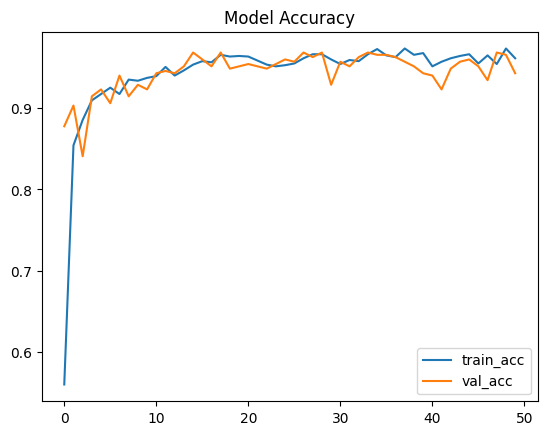

In [59]:
#Plot Training Performance

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [60]:
#Improve the Mode
#Add Dropout (reduce overfitting)

layers.Dropout(0.3)

<Dropout name=dropout, built=True>

In [61]:
layers.Dropout(0.3)

#Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5)

model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9773 - loss: 0.0583 - val_accuracy: 0.9773 - val_loss: 0.0752
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9702 - loss: 0.0785 - val_accuracy: 0.9602 - val_loss: 0.1047
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9730 - loss: 0.0630 - val_accuracy: 0.9517 - val_loss: 0.0921
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9702 - loss: 0.0664 - val_accuracy: 0.9545 - val_loss: 0.1077
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9659 - loss: 0.0777 - val_accuracy: 0.9688 - val_loss: 0.1093
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9751 - loss: 0.0612 - val_accuracy: 0.9602 - val_loss: 0.1012


In [62]:
#Compare with Random Forest

from sklearn.metrics import accuracy_score

print("RF Accuracy:", rf_acc)
print("DL Accuracy:", accuracy)

RF Accuracy: 0.9954545454545455
DL Accuracy: 0.949999988079071


In [63]:
import requests

API_KEY = "6ba29dc3cec671f8c2fd41b3aeb630a4"  # replace with valid key
city = "Thiruvananthapuram"

url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)
data = response.json()

# Debug response
print("API Response:", data)

# Safe extraction
if response.status_code == 200 and 'main' in data:
    temperature = data['main']['temp']
    humidity = data['main']['humidity']

    rainfall = data.get('rain', {}).get('1h', 0)

    print("Temperature:", temperature)
    print("Humidity:", humidity)
    print("Rainfall:", rainfall)

else:
    print("Error:", data.get('message', 'Unknown error'))

API Response: {'coord': {'lon': 76.9167, 'lat': 8.4833}, 'weather': [{'id': 802, 'main': 'Clouds', 'description': 'scattered clouds', 'icon': '03n'}], 'base': 'stations', 'main': {'temp': 27.99, 'feels_like': 31.77, 'temp_min': 27.99, 'temp_max': 27.99, 'pressure': 1008, 'humidity': 78, 'sea_level': 1008, 'grnd_level': 1008}, 'visibility': 6000, 'wind': {'speed': 2.57, 'deg': 350}, 'clouds': {'all': 40}, 'dt': 1778606097, 'sys': {'type': 1, 'id': 9226, 'country': 'IN', 'sunrise': 1778546043, 'sunset': 1778591006}, 'timezone': 19800, 'id': 1254163, 'name': 'Trivandrum', 'cod': 200}
Temperature: 27.99
Humidity: 78
Rainfall: 0


In [64]:
#Handle Rainfall

rainfall = data.get('rain', {}).get('1h', 0)  # rainfall in last 1 hour

In [65]:
#Combine API Data with Model Input

input_data = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': temperature,
    'humidity': humidity,
    'ph': 6.5,
    'rainfall': rainfall
}

In [66]:
#Predict Crop Automatically

result = predict_crop(input_data, rf_model, scaler, le)
print("Recommended Crop:", result)

Recommended Crop: kidneybeans


C:\Users\sanan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [67]:
#Improve Accuracy with Location

lat = 8.5241
lon = 76.9366

url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"

In [68]:
import joblib
joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [69]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import streamlit as st
import numpy as np
import joblib

# Load saved files
model = joblib.load('crop_model.pkl')
scaler = joblib.load('scaler.pkl')
le = joblib.load('label_encoder.pkl')

st.title("🌱 Crop Recommendation System")

st.write("Enter soil and environmental parameters:")

# Input fields
N = st.number_input("Nitrogen (N)", min_value=0)
P = st.number_input("Phosphorus (P)", min_value=0)
K = st.number_input("Potassium (K)", min_value=0)
temperature = st.number_input("Temperature (°C)")
humidity = st.number_input("Humidity (%)")
ph = st.number_input("pH value")
rainfall = st.number_input("Rainfall (mm)")

# Prediction
if st.button("Predict Crop"):
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    crop = le.inverse_transform(prediction)
    
    st.success(f"Recommended Crop: {crop[0]}")

FileNotFoundError: [Errno 2] No such file or directory: 'crop_model.pkl'

In [ ]:

streamlit run app.py

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &
public_url = ngrok.connect(8501)
public_url

In [ ]:
import requests

def get_weather(city, api_key):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    data = requests.get(url).json()
    
    temp = data.get('main', {}).get('temp')
    hum = data.get('main', {}).get('humidity')
    rain = data.get('rain', {}).get('1h', 0)
    
    return temp, hum, rain